# TWII Next-Day Return Forecasting — Pipeline

A single **LightGBM** regressor predicting the **next-day log return** of the Taiwan
Weighted Index (`^TWII`). The deliverable is *predictive power vs. naive baselines*,
not a trading book.

> Honest expectation: out-of-sample R² on daily returns is near zero or negative, and
> 51–54% directional accuracy is a **good** result. A dramatically higher number on a
> single split is leakage, not alpha.

This notebook is deliberately thin — all logic lives in `src/twii_forecast/`.

In [13]:
# autoreload so edits under src/ are picked up without restarting the kernel
import sys, logging
sys.path.insert(0, "../src")        # import the package without installing
logging.basicConfig(level=logging.INFO, format="%(message)s")

import numpy as np
import pandas as pd
from IPython.display import display

from twii_forecast import (
    config, data, dataset, split, scaling, model, evaluate, monitor, plots,
    feature_selection,
)
from twii_forecast.dataset import split_xy
np.random.seed(config.SEED)

AttributeError: module 'twii_forecast.config' has no attribute 'TEMPORAL_PERIOD_MONTHS'

## 1. Leakage gate — run it FIRST and fail loudly

The correctness gate `tests/test_leakage.py` must pass before trusting anything below
(every rolling op is trailing; the target is strictly `ln(C_{t+1}/C_t)`; features are
provably causal). This cell **raises** if the gate does not pass, so the notebook
cannot silently proceed on leaky features.

In [ ]:
import subprocess
gate = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "tests/test_leakage.py"],
    capture_output=True, text=True, cwd="..",
)
print(gate.stdout or gate.stderr)
assert gate.returncode == 0, "LEAKAGE GATE FAILED — fix before trusting results below"
print("✓ leakage gate passed")

....                                                                     [100%]
4 passed in 0.93s

✓ leakage gate passed


## 2. Data + volume data-quality gate

In [ ]:
df, use_volume = data.load()
print(f"rows={len(df)}  {df.index[0].date()} → {df.index[-1].date()}  use_volume={use_volume}")
df.tail()

Loading cached raw data from /Users/wanchuan/quant-demo/data/raw/twii.parquet
Volume gate: zero=0.003 nan=0.000 degenerate=0.003 (threshold 0.05)


rows=2773  2015-01-05 → 2026-06-05  use_volume=True


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-06-01,44872.820312,45931.101562,44872.820312,45337.910156,9887600
2026-06-02,45388.929688,45915.921875,44869.378906,45557.308594,11590000
2026-06-03,45660.460938,46552.160156,45660.460938,46459.160156,11629900
2026-06-04,46364.070312,46364.070312,45677.460938,45677.460938,10148400
2026-06-05,45619.820312,45619.820312,44209.531250,45070.941406,8445300


## 3. Features → target → dataset (warmup + tail NaNs dropped)

In [ ]:
frame = dataset.build_dataset(df, use_volume=use_volume)
X_all, y_all = split_xy(frame)
print(f"{frame.shape[0]} rows × {X_all.shape[1]} features")
X_all.tail()

Dataset: 2712 rows after warmup+dropna (from 2773), 37 feature cols


2712 rows × 37 features


,amplitude,difference,h_minus_l,c_minus_o,delta_close,delta_volume,intraday,intraday_ma5,delta_close_ma5,delta_volume_ma5,...,ma60,ema60,macd,bb_high,bb_low,ret_lag0,ret_lag1,ret_lag2,ret_lag3,ret_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-29,0.025632,0.021025,1118.468750,917.460938,1096.500000,1671800.0,604.359375,-284.646875,492.994531,982820.0,...,37264.192285,38186.426249,1596.934617,44722.997896,38856.521450,0.024818,-0.014116,0.016665,-0.002731,0.021517
2026-06-01,0.023658,0.010397,1058.281250,465.089844,604.968750,-2730700.0,-917.460938,-304.129687,338.702344,277460.0,...,37472.676139,38420.901131,1688.235020,45110.151747,39079.965813,0.013433,0.024818,-0.014116,0.016665,0.032045
2026-06-02,0.023083,0.003714,1046.542969,168.378906,219.398438,1702400.0,-465.089844,-201.842187,406.387500,87980.0,...,37670.748926,38654.881704,1758.029399,45624.238368,39027.990427,0.004828,0.013433,0.024818,-0.014116,-0.002731
2026-06-03,0.019573,0.017532,891.699219,798.699219,901.851562,39900.0,-168.378906,-272.221875,440.471875,202820.0,...,37885.075944,38910.759686,1864.619656,46271.426478,38922.694802,0.019603,0.004828,0.013433,0.024818,0.016665
2026-06-04,0.014779,-0.014779,686.609375,-686.609375,-781.699219,-1481500.0,-798.699219,-349.053906,408.203906,-159620.0,...,38111.193294,39132.618743,1864.523542,46657.307949,38969.061842,-0.016969,0.019603,0.004828,0.013433,-0.014116


## 4. Chronological split (85 / 5 / 10)

Oldest 85% train, next 5% validation, newest 10% test — no shuffling. Feature selection and the scaler are both derived from **train only**.


In [ ]:
sp = split.chronological_split(frame)
X_tr, y_tr = split_xy(sp.train)
X_va, y_va = split_xy(sp.val)
X_te, y_te = split_xy(sp.test)


## 4b. Feature selection — temporal consistency analysis (CalixBoost §3.2.3.2)

Split the **training** series into consecutive 3-month (*trimonthly*) periods, learn each
feature's up/down direction on one period, and measure its ROC-AUC when that direction is
carried to every other non-overlapping period. A feature whose mean out-of-period AUC stays
at or above the paper's **0.5** threshold generalises across time and is **kept**; one that
sinks below 0.5 was predictive only in-sample and is **dropped**. Run on train only — selecting
on val/test would leak. The kept subset flows into scaling, training and evaluation below.


In [ ]:
kept, tc = feature_selection.select_features(X_tr, y_tr)

# Persist the full AUC table for the record, then restrict every split to survivors.
report = tc.report_frame()
report.to_csv(config.REPORTS_DIR / "temporal_consistency.csv")
X_tr, X_va, X_te = X_tr[kept], X_va[kept], X_te[kept]

print(f"{tc.n_periods} trimonthly periods, {tc.period_pairs} ordered pairs, "
      f"AUC >= {tc.threshold}: kept {len(kept)} / {tc.summary.shape[0]} features")
if tc.dropped:
    print("dropped (temporally inconsistent):", ", ".join(tc.dropped))
display(report.round(4))


## 4c. RobustScaler (IQR) — fit on TRAIN only

Fit on the train split of the **selected** features, applied unchanged to val/test.


In [ ]:
scaler = scaling.fit_scaler(X_tr)
X_tr_s = scaling.transform(scaler, X_tr)
X_va_s = scaling.transform(scaler, X_va)
X_te_s = scaling.transform(scaler, X_te)


## 5. Train: random search on validation MAE, refit best

In [ ]:
result = model.train(X_tr_s, y_tr, X_va_s, y_va,
                     n_draws=config.N_SEARCH_DRAWS, progress=True)
model.save(result)
print(f"best val MAE = {result.val_mae:.6e} at {result.best_iteration} trees")
result.params

random search:   0%|          | 0/40 [00:00<?, ?it/s]

Best val MAE=1.136666e-02 at 12 trees: {'num_leaves': 63, 'learning_rate': 0.052682120094788454, 'max_depth': 5, 'min_child_samples': 10, 'feature_fraction': 0.7251929689477836, 'bagging_fraction': 0.6853990121162906, 'lambda_l1': 4.633824944243009, 'lambda_l2': 3.2193256004033226}
Saved model -> /Users/wanchuan/quant-demo/models/lgbm.txt and params -> /Users/wanchuan/quant-demo/models/best_params.json


best val MAE = 1.136666e-02 at 12 trees


{'num_leaves': 63,
 'learning_rate': 0.052682120094788454,
 'max_depth': 5,
 'min_child_samples': 10,
 'feature_fraction': 0.7251929689477836,
 'bagging_fraction': 0.6853990121162906,
 'lambda_l1': 4.633824944243009,
 'lambda_l2': 3.2193256004033226}

## 6. Evaluation — every metric next to its baseline

In [ ]:
y_pred = model.predict(result.model, X_te_s)
table = evaluate.evaluate(y_te, y_pred, y_tr)
display(table.round(5))
table.round(5)

,MAE,RMSE,DirAcc,IC,R2
model,,,,,
LightGBM,0.01056,0.01377,0.58824,0.01659,-0.02578
Persistence (0),0.01069,0.01394,NaN,NaN,-0.05150
Historical mean,0.01062,0.01386,0.59191,0.00000,-0.03972


,MAE,RMSE,DirAcc,IC,R2
model,,,,,
LightGBM,0.01056,0.01377,0.58824,0.01659,-0.02578
Persistence (0),0.01069,0.01394,NaN,NaN,-0.05150
Historical mean,0.01062,0.01386,0.59191,0.00000,-0.03972


**Reading the table.** *Persistence (0)* is the number to beat on MAE/RMSE.
DirAcc near 0.50–0.54 is the realistic band; *Historical mean* predicts a constant
sign, so its DirAcc just reflects how directional the test window happened to be.

## 7. Monitoring — train-vs-test data drift (evidently)

In [ ]:
drift = monitor.drift_report(X_tr, X_te)
print("drift report →", config.REPORTS_DIR / "drift_train_vs_test.html")

Saved drift report -> /Users/wanchuan/quant-demo/reports/drift_train_vs_test.html


drift report → /Users/wanchuan/quant-demo/reports/drift_train_vs_test.html


## 8. Plots

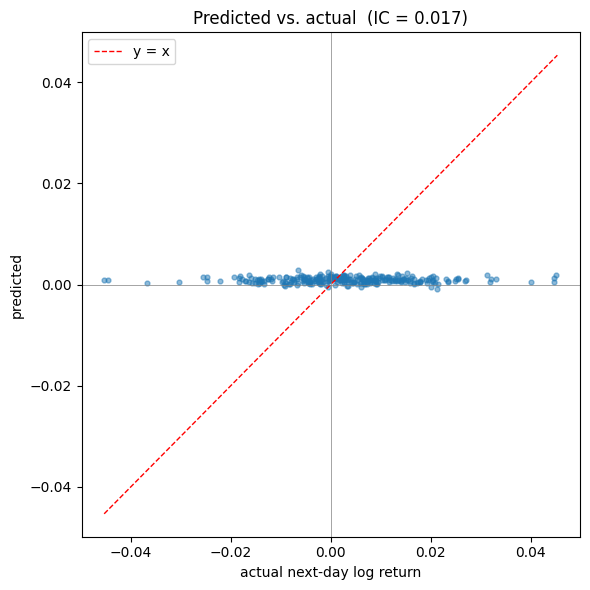

In [ ]:
ic = float(np.corrcoef(y_pred, y_te.to_numpy())[0, 1])
plots.pred_vs_actual(y_te, y_pred, ic)

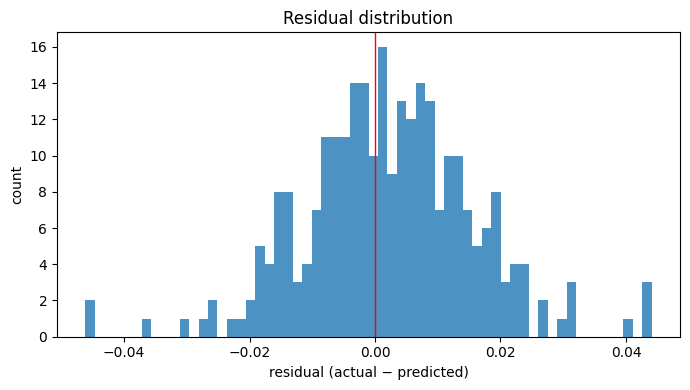

In [ ]:
plots.residual_hist(y_te, y_pred)

### Next-day directional accuracy (single-period — **not** compounded)

Each test day is an independent up/down call (`sign(pred) == sign(actual)`). We do not
compound predicted returns into a price level: a small per-step return bias compounds
into a large, misleading level gap, so direction is evaluated one day at a time.

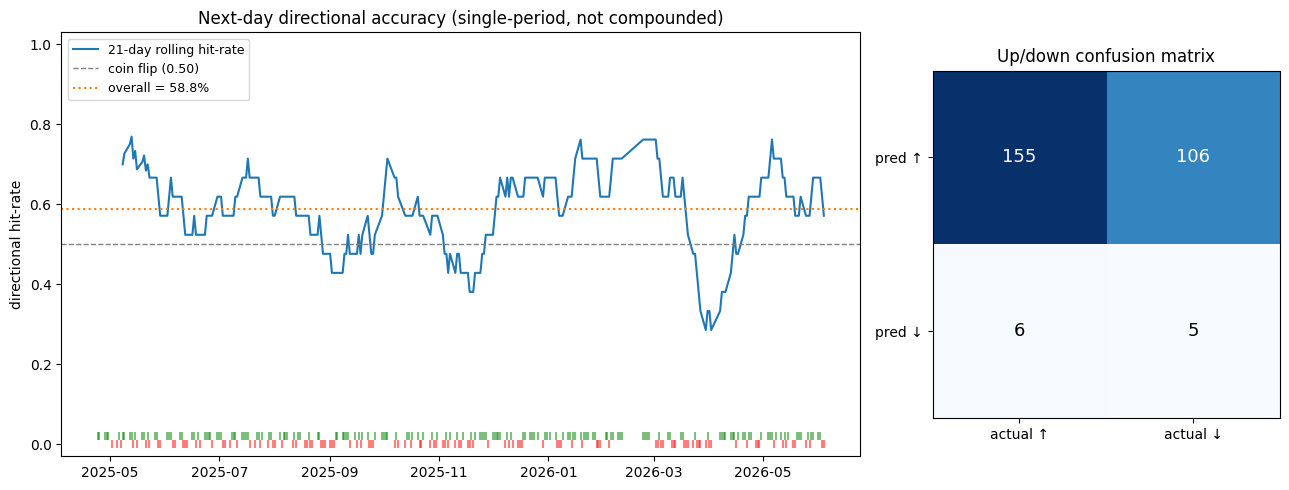

In [ ]:
plots.directional_accuracy(y_te, y_pred)

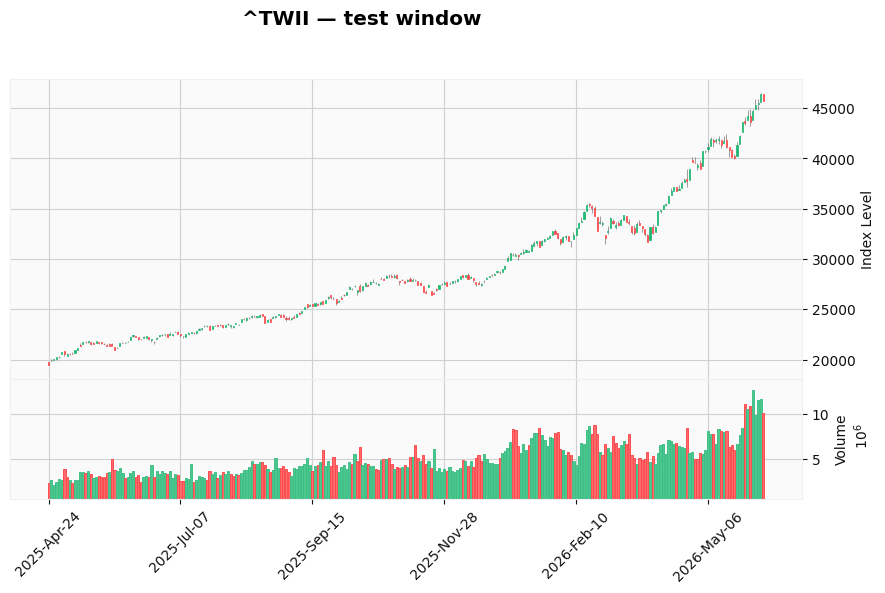

In [ ]:
plots.candles(df, y_te.index, use_volume=use_volume)

---
### Takeaway

The model's edge over persistence on daily returns is small — exactly as expected for
single-index next-day forecasting. What makes this credible is that **every metric is
reported against a baseline** and the **leakage gate passes**; the honest near-zero R²
is the finding, not a bug.